# IIA 2024 - Aprendizaje Automatizado

## Introducción a Jupyter Notebooks y Generación de Datos

## Bertoni Juan Ignacio, Goñi Martín y Wasserstrom Lucas Nicolas

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from typing import Tuple

## Diagonales

Generar n datos con d inputs:

  - n/2 pertenecientes a la categoría 0. Esta clase corresponde a puntos generados al azar, provenientes de una distribución normal, con centro en el (-1, -1, -1, ... , -1) y matriz de covarianza diagonal, con desviación estándar igual a C * SQRT(d).
  - n/2 pertenecientes a la categoría 1. Esta clase corresponde a puntos generados al azar, provenientes de una distribución normal, con centro en el (1, 1, 1, ... ,1) y matriz de covarianza diagonal, con desviación estándar igual a C * SQRT(d).


In [67]:
def diagonales(d: int, C: float, n: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Genera sampleos de dos gausianas d-dimensionales en posición diagonal
    (una respecto a la otra), con dispersión C * sqrt(d).
    Cada sampleo posee n/2 puntos.

    Argumentos:
        d: número de dimensiones
        C: constante de ajuste de dispersión
        n: número de ejemplos a generar

    Retorna:
        X: matriz con d columnas y n filas de datos
        y: arreglo de n elementos con las clases correspondientes
            a cada fila de datos
    """    
    # Start rng generator
    rng = np.random.default_rng()
    class_num = int((n + n % 2) / 2)
    # Standard deviation
    s_d = C * np.sqrt(d)

    class_1_center = np.ones(d)
    class_0_center = (-1) * np.ones(d)

    v_1 = rng.normal(loc=class_1_center, scale=s_d, size=(class_num, d))
    v_0 = rng.normal(loc=class_0_center, scale=s_d, size=(class_num, d))

    X = np.concatenate((v_1, v_0), axis=0)

    y_1 = np.ones(class_num)
    y_0 = np.zeros(class_num)
    y = np.concatenate((y_1, y_0))

    return X, y

Verificamos ahora los datos generados, mostrándolos con matplotlib.pyplot

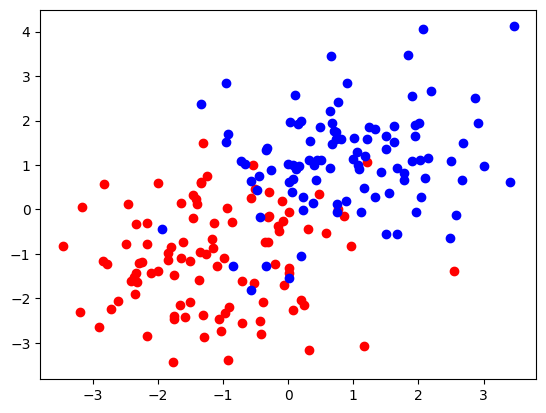

In [83]:
diag_X, diag_y = diagonales(2, 0.75, 200)

mask_0 = diag_y == 0
mask_1 = diag_y == 1

plt.scatter(diag_X[mask_0][:, 0], diag_X[mask_0][:, 1], color='red', label='Class 0')
plt.scatter(diag_X[mask_1][:, 0], diag_X[mask_1][:, 1], color='blue', label='Class 1')
plt.show()

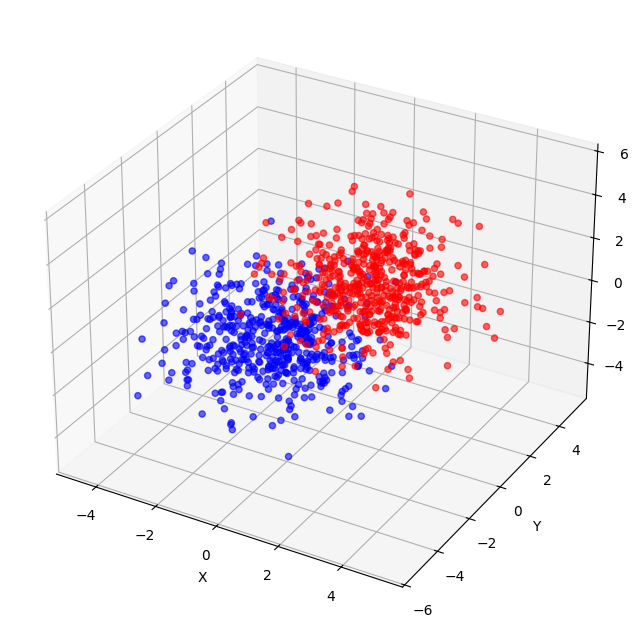

In [ ]:
diag_X, diag_y = diagonales(3, 0.75, 1000)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(diag_X[diag_y == 0, 0], diag_X[diag_y == 0, 1], diag_X[diag_y == 0, 2], c='blue', label='Class 0', alpha=0.6)
ax.scatter(diag_X[diag_y == 1, 0], diag_X[diag_y == 1, 1], diag_X[diag_y == 1, 2], c='red', label='Class 1', alpha=0.6)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()


## Paralelas

Igual al punto anterior, pero las distribuciones tienen centro en el ( 1, 0, 0, .... , 0 ) y en el ( -1, 0, 0, .... , 0 ), respectivamente y la desviación estandar es igual a C independientemente de d.

In [71]:
def paralelas(d: int, C: float, n: int) -> Tuple[np.ndarray, np.ndarray]:
    # Start rng generator
    rng = np.random.default_rng()
    class_num = int((n + n % 2) / 2)
    # Standard deviation
    s_d = C * np.sqrt(d)

    z_a = np.zeros(d - 1)
    class_1_center = np.concatenate(([1], z_a))
    class_0_center = np.concatenate(([-1], z_a))

    v_1 = rng.normal(loc=class_1_center, scale=s_d, size=(class_num, d))
    v_0 = rng.normal(loc=class_0_center, scale=s_d, size=(class_num, d))

    X = np.concatenate((v_1, v_0), axis=0)

    y_1 = np.ones(class_num)
    y_0 = np.zeros(class_num)
    y = np.concatenate((y_1, y_0))

    return X, y 

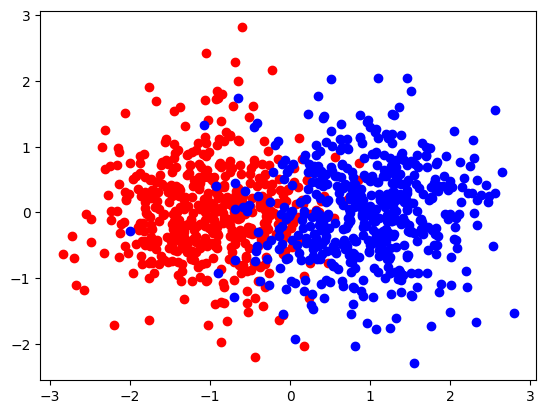

In [159]:
diag_X, diag_y = paralelas(2, 0.5, 1000)

mask_0 = diag_y == 0
mask_1 = diag_y == 1

plt.scatter(diag_X[mask_0][:, 0], diag_X[mask_0][:, 1], color='red', label='Class 0')
plt.scatter(diag_X[mask_1][:, 0], diag_X[mask_1][:, 1], color='blue', label='Class 1')
plt.show()

## Espirales

Generar n datos. De los n puntos generados, n/2 deben pertenecer a cada clase.

Los datos tienen 2 inputs, x e y, que corresponden a puntos generados al azar con una distribución UNIFORME (en dicho sistema de referencia x-y) dentro de un circulo de radio 1.

El output es binario, correspondiendo la clase 0 a los puntos que se encuentran entre las curvas ro = theta/4pi y ro = (theta + pi)/4pi (en polares) y la clase 1 al resto.

In [264]:
def espirales(n: int) -> Tuple[np.ndarray, np.ndarray]:

    c_0 = []
    c_1 = []

    rng = np.random.default_rng()
    class_num = int((n + n % 2) / 2)

    """
    count_1 = 0
    while (count_1 < class_num):
        r = rng.uniform(low=0, high=1)
        a = rng.uniform(low=0, high=2 * np.pi)
    
        for n in [-1, 1, 3]:
            l = (n * np.pi + a) / (4 * np.pi)
            u = (n * np.pi + (a + np.pi)) / (4 * np.pi)
            
            if r >= l and r <= u:
                c_0.append([r * np.cos(a), r * np.sin(a)])
                count_1 += 1
                break

    count_2 = 0
    while (count_2 < class_num):
        r = rng.uniform(low=0, high=1)
        a = rng.uniform(low=0, high=2 * np.pi)
    
        for n in [0, 2, 4]:
            l = (n * np.pi + a) / (4 * np.pi)
            u = (n * np.pi + (a + np.pi)) / (4 * np.pi)
            
            if r <= l and r >= u:
                c_0.append([r * np.cos(a), r * np.sin(a)])
                count_1 += 1
                break
    """
    # p_1 = (t + pi)/4pi
    p_1 = rng.uniform(low=-np.pi, high=4 * np.pi, size=class_num)
    # Clase 0, adentro de las curvas
    for angle in p_1:
        d1 = max(0, angle / (4 * np.pi))
        d2 = min(1, (angle + np.pi) / (4 * np.pi))

        r = rng.uniform(low=d1, high=d2)

        #print(f"r:{r} - angle: {angle} - ap: {angle / np.pi} - cos:{np.cos(angle)} - sin:{np.sin(angle)}")

        c_0.append([r * np.cos(angle), r * np.sin(angle)])
    
    # p_2 = t/4pi
    p_2 = rng.uniform(low=2, high=5 * np.pi, size=class_num)
    # Clase 1, afuera de las curvas
    for angle in p_2:
        d1 = (angle - np.pi) / (4 * np.pi)
        d2 = min(1, angle / (4 * np.pi))

        #print(f"r:{r} - angle: {angle} - ap: {angle / np.pi} - d1: {d1} - d2:{d2} -cos:{np.cos(angle)} - sin:{np.sin(angle)}")

        r = rng.uniform(low=d1, high=d2)
        c_1.append([r * np.cos(angle), r * np.sin(angle)])

    return (np.array(c_0).T, np.array(c_1).T)

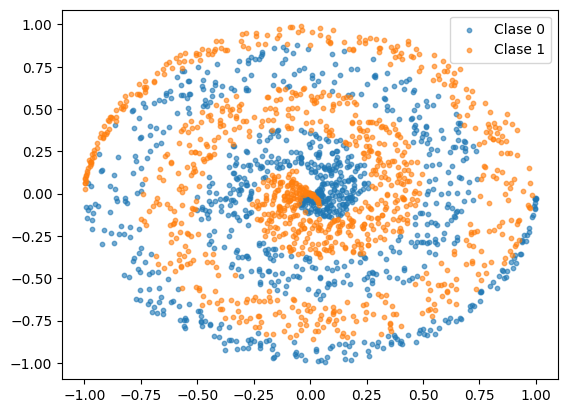

In [265]:
(c_0, c_1) = espirales(2000)

plt.close()
plt.scatter(c_0[0, :], c_0[1, :], label='Clase 0', alpha=0.6, s=10)
plt.scatter(c_1[0, :], c_1[1, :], label='Clase 1', alpha=0.6, s=10)
plt.legend()
plt.show()
